In [ ]:
#!pip install newsapi-python

In [ ]:
#!pip install langchain_ollama

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnableWithMessageHistory
from langchain_ollama import ChatOllama
from langchain_core.chat_history import BaseChatMessageHistory
from langchain_core.messages import get_buffer_string, AIMessage, HumanMessage
from langchain_core.output_parsers import JsonOutputParser
from typing import Dict
import networkx as nx  # For graph memory (pip install networkx if needed)

llm = ChatOllama(model="mistral", temperature=0.5)
store: Dict[str, BaseChatMessageHistory] = {}
config = {"configurable": {"session_id": "rahul_trip"}}

prompt = ChatPromptTemplate.from_template(
    "Travel bot: Use history.\n{history}\nHuman: {input}\nBot:"
)
base_chain = prompt | llm

In [ ]:
from langchain_core.chat_history import InMemoryChatMessageHistory

def get_buffer_history(session_id: str):
    if session_id not in store: store[session_id] = InMemoryChatMessageHistory()
    return store[session_id]

buffer_chain = RunnableWithMessageHistory(base_chain, get_buffer_history, 
                                          input_messages_key="input", 
                                          history_messages_key="history")

# Demo: 3 turns
queries = ["Plan Mumbai trip.", "Budget: 50k INR.", "Include beaches?"]
for q in queries:
    resp = buffer_chain.invoke({"input": q}, config=config)
    print(f"Bot: {resp.content[:100]}...")  # Truncated
print(f"History len: {len(store['rahul_trip'].messages)}")


In [ ]:
store['rahul_trip']

class SummaryHistory(BaseChatMessageHistory):: Extends base—what? Inherit load/add methods. Why import BaseChatMessageHistory? From langchain_core.chat_history—abstract for custom (e.g., file/DB).
__init__: Sets session, llm (for summarizing), empty lists—why? State per instance.

add_messages(self, messages):: Override—what? Appends raw, triggers summary every 3. Why? Wrapper calls this post-response.

self.full_history.extend(messages): Keeps all—why? Fallback if needed.
if len(...) % 3 == 0: Conditional—why? Batch for efficiency (tune to %5).
sum_prompt = ... | self.llm | (lambda x: x.content): LCEL sub-chain—what? Template to summarize, pipe LLM, extract content. Why? Reusable.
self.summary = sum_prompt.invoke({"chat": get_buffer_string(self.full_history)}): Invokes—what? Formats history string (from langchain_core.messages—why import? Utils like get_buffer_string). Updates summary.

messages(self):: Override—what? Returns recent 2 + summary as AIMessage. Why? Wrapper formats this into {history}—keeps prompt short.

The rest (get_summary_history, summary_chain, invoke) mirrors buffer—why? Reusability; just swap factory.

In [ ]:
class SummaryHistory(BaseChatMessageHistory):
    def __init__(self, session_id: str, llm):
        self.session_id = session_id; self.llm = llm; self.full_history = []; self.summary = ""

    def add_messages(self, messages):
        self.full_history.extend(messages)
        if len(self.full_history) % 3 == 0:  # Summarize every 3
            sum_prompt = ChatPromptTemplate.from_template("Summarize trip plan: {chat}") | self.llm | (lambda x: x.content)
            self.summary = sum_prompt.invoke({"chat": get_buffer_string(self.full_history)})

    def messages(self):
        return self.full_history[-2:] + [AIMessage(content=f"Summary: {self.summary}")]

def get_summary_history(session_id: str):
    if session_id not in store: store[session_id] = SummaryHistory(session_id, llm)
    return store[session_id]

summary_chain = RunnableWithMessageHistory(base_chain, get_summary_history, input_messages_key="input", history_messages_key="history")

# Demo
resp = summary_chain.invoke({"input": "Add flight to Delhi."}, config=config)
print("Bot (with summary):", resp.content)

__init__: Adds self.entities = {}—what? Dict for extracted facts (e.g., {"pref": "AC"}). Why? Structured recall.

In [ ]:
class EntityHistory(BaseChatMessageHistory):
    def __init__(self, session_id: str, llm):
        self.session_id = session_id; self.llm = llm; self.full_history = []; self.entities = {}

    def add_messages(self, messages):
        self.full_history.extend(messages)
        ent_prompt = ChatPromptTemplate.from_template('Extract JSON: {"pref": "desc"} from: {chat}') | self.llm | JsonOutputParser()
        new_ents = ent_prompt.invoke({"chat": get_buffer_string(messages)})
        self.entities.update(new_ents)

    def messages(self):
        ent_str = "\n".join(f"{k}: {v}" for k,v in self.entities.items())
        return self.full_history[-2:] + [AIMessage(content=f"Entities: {ent_str}")]

def get_entity_history(session_id: str):
    if session_id not in store: store[session_id] = EntityHistory(session_id, llm)
    return store[session_id]

entity_chain = RunnableWithMessageHistory(base_chain, get_entity_history, input_messages_key="input", history_messages_key="history")

# Demo
resp = entity_chain.invoke({"input": "Rahul prefers AC hotels, hates delays."}, config=config)
print("Bot:", resp.content)
print("Entities:", store['rahul_trip'].entities)  # {'pref': 'AC hotels, no delays'}

In [ ]:
from typing import Dict
from langchain_core.chat_history import BaseChatMessageHistory

# Re-define store (from shared setup)
store: Dict[str, BaseChatMessageHistory] = {}
print("✅ Store re-defined!")

In [ ]:
store.clear()  # Resets store—fresh for graph

Entity is flat—graph adds edges (e.g., Rahul → Mumbai:rainy). Why? Multi-hop (e.g., "Rainy prefs? Traverse").

add_messages: Scans for keywords, adds edges—what? Mock extraction (real: LLM triples). Why? Builds web incrementally.

messages: Stringifies edges—what? Prompt sees relations. Why? LLM reasons over "Rahul --trip_to--> Mumbai (rainy)".

In [ ]:
class GraphHistory(BaseChatMessageHistory):
    def __init__(self, session_id: str):
        self.session_id = session_id; self.full_history = []; self.graph = nx.DiGraph()  # Simple graph

    def add_messages(self, messages):
        self.full_history.extend(messages)
        # Mock extraction: Add nodes/edges (use LLM for real)
        for msg in messages:
            if "Mumbai" in msg.content: self.graph.add_edge("Rahul", "Mumbai", rel="trip_to", attr="rainy")
            if "indoor" in msg.content: self.graph.add_edge("Mumbai", "sites", rel="prefers", attr="museums")
    
    @property
    def messages(self):
        graph_str = "\n".join(f"{u} --{d['rel']}--> {v} ({d['attr']})" for u,v,d in self.graph.edges(data=True))
        return self.full_history[-2:] + [AIMessage(content=f"Graph: {graph_str}")]

    def clear(self):
        self.full_history=[]
        self.graph.clear()
        
def get_graph_history(session_id: str):
    if session_id not in store: store[session_id] = GraphHistory(session_id)
    return store[session_id]

graph_chain = RunnableWithMessageHistory(base_chain, get_graph_history, input_messages_key="input", history_messages_key="history")

# Demo
resp = graph_chain.invoke({"input": "Suggest indoor sites for rainy Mumbai."}, config=config)
print("Bot (graph-aware):", resp.content)
#print("Graph edges:", list(store['rahul_trip'].graph.edges(data=True)))

In [ ]:
store['rahul_trip'].graph.edges(data=True)

In [12]:
import networkx as nx
import json

from langchain_core.chat_history import BaseChatMessageHistory
from langchain_core.messages import AIMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.runnables.history import RunnableWithMessageHistory

In [17]:
triple_prompt = ChatPromptTemplate.from_template(
"""
Extract knowledge graph triples from the text.

Return ONLY JSON in this format:

[
  {{"subject":"...","relation":"...","object":"..."}}
]

Text:
{chat}
"""
)

In [18]:
class GraphHistory(BaseChatMessageHistory):

    def __init__(self, session_id, llm):
        self.session_id = session_id
        self.llm = llm
        self.full_history = []
        self.graph = nx.DiGraph()

    def add_messages(self, messages):

        self.full_history.extend(messages)

        chat_text = "\n".join([m.content for m in messages])

        chain = triple_prompt | self.llm

        response = chain.invoke({"chat": chat_text})

        try:
            triples = json.loads(response.content)
        except:
            triples = []

        for t in triples:
            s = t["subject"]
            r = t["relation"]
            o = t["object"]

            self.graph.add_edge(s, o, rel=r)

    @property
    def messages(self):

        edges = [
            f"{u} --{d['rel']}--> {v}"
            for u,v,d in self.graph.edges(data=True)
        ]

        graph_text = "\n".join(edges)

        return self.full_history[-2:] + [
            AIMessage(content=f"Graph Memory:\n{graph_text}")
        ]

    def clear(self):
        self.full_history = []
        self.graph.clear()

In [19]:
store = {}

In [20]:
def get_graph_history(session_id):

    if session_id not in store:
        store[session_id] = GraphHistory(session_id, llm)

    return store[session_id]

In [21]:
prompt = ChatPromptTemplate.from_messages([
    ("system","You are a travel assistant."),
    MessagesPlaceholder(variable_name="history"),
    ("human","{input}")
])

In [22]:
base_chain = prompt | llm

In [23]:
graph_chain = RunnableWithMessageHistory(
    base_chain,
    get_graph_history,
    input_messages_key="input",
    history_messages_key="history"
)

In [24]:
config = {"configurable":{"session_id":"graph_demo"}}

graph_chain.invoke(
    {"input":"I want to visit Mumbai and I love museums"},
    config=config
)

graph_chain.invoke(
    {"input":"Suggest indoor activities there"},
    config=config
)

AIMessage(content=" If you're looking for indoor activities to do while in Mumbai, here are some suggestions that you might find interesting:\n\n1. Visit theaters and live performances: Mumbai is home to several theaters and performance venues where you can watch plays, musicals, and other live performances. Some popular venues include Prithvi Theatre, NCPA, and the Royal Opera House.\n2. Explore museums: As mentioned earlier, Mumbai has a rich collection of museums that showcase Indian art, history, culture, and natural history. Some of the top museums in Mumbai include Chhatrapati Shivaji Maharaj Vastu Sangrahalaya (CSMVS), Dr. Bhau Daji Lad Museum, National Museum of Indian Cinema, Jamshed Bhabha Museum, and Asiatic Society of Mumbai.\n3. Try a cooking class: If you're interested in learning about Indian cuisine, you can take a cooking class to learn how to prepare traditional Indian dishes. Some popular cooking schools in Mumbai include Sanjay Thumma's Cooking Studio and the Bombay

In [25]:
for u,v,d in store["graph_demo"].graph.edges(data=True):
    print(u,"--",d["rel"],"-->",v)

You -- can attend a yoga class in --> Mumbai
You -- has_passion_for --> museums
You -- are looking for --> indoor activities
You -- can take --> a cooking class
Mumbai -- is home to --> theaters and live performances
Mumbai -- has --> museums
Mumbai -- has --> art galleries
Mumbai -- has --> spas and wellness centers
Mumbai -- has --> a planetarium
Chhatrapati Shivaji Maharaj Vastu Sangrahalaya (CSMVS) -- is_located_near --> Gateway of India
Chhatrapati Shivaji Maharaj Vastu Sangrahalaya (CSMVS) -- showcases --> Indian art and archaeology, natural history, and world culture
Dr. Bhau Daji Lad Museum -- is_situated_in --> Byculla
Dr. Bhau Daji Lad Museum -- showcases --> cultural and historical heritage of Mumbai
National Museum of Indian Cinema -- is_located_at --> Mumbai's Film City
National Museum of Indian Cinema -- showcases --> evolution of Indian cinema
Jamshed Bhabha Museum -- is_situated_within --> NGMA complex in Mumbai
Jamshed Bhabha Museum -- focuses_on --> modern and contemp

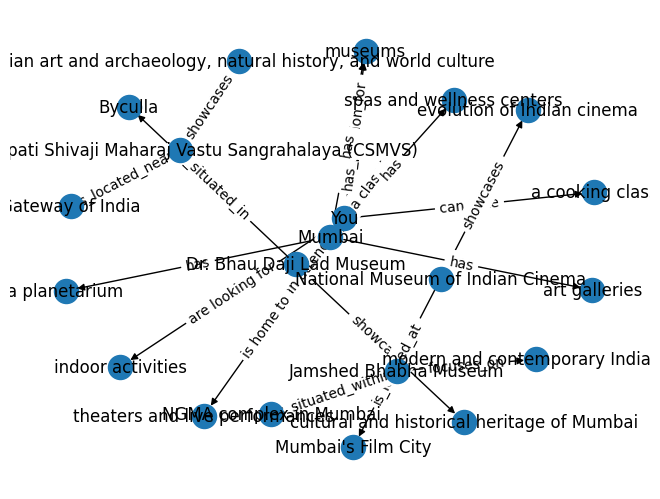

In [26]:
import matplotlib.pyplot as plt

g = store["graph_demo"].graph
pos = nx.spring_layout(g)

nx.draw(g, pos, with_labels=True)
nx.draw_networkx_edge_labels(
    g,
    pos,
    edge_labels={(u,v):d["rel"] for u,v,d in g.edges(data=True)}
)

plt.show()

In [ ]:
from langchain.tools import tool

@tool
def hello_tool(name: str):
    return f"Hello {name}"

In [ ]:
hello_tool.invoke({"name":"Rahul"})

In [ ]:
import requests
from langchain.tools import tool

@tool
def get_bitcoin_price():
    url = "https://api.coindesk.com/v1/bpi/currentprice.json"
    data = requests.get(url).json()
    return data["bpi"]["USD"]["rate"]

In [ ]:
import requests
from langchain.tools import tool

@tool
def wiki_search(query: str):
    url = f"https://en.wikipedia.org/api/rest_v1/page/summary/{query}"
    data = requests.get(url).json()
    return data["extract"]

# 🔧 Empower Your Bot: Tools for Real-World Actions

Memory recalls *past*—tools fetch *now*. Picture Rahul's bot: "Mumbai news?" Mistral can't Google—hallucinates "Sunny skies!" Tools fix that: Bind functions (e.g., API calls) so LLM *decides* when to use them ("Reason: Need live data → Call get_travel_news"). Output? Structured `tool_calls` JSON—parse, execute, feed back.

In 0.4+, it's LCEL-pure: `@tool def func(args):` → `llm.bind_tools([func])` → Chain invoke. Why realistic? No mocks—connect NewsAPI (free headlines on "Mumbai travel"). Handles errors, parses JSON—feels prod-ready.

Demo Flow: Query → LLM suggests call → We run tool → Mock final response. Tease: This + memory = "Rahul, recall your prefs + breaking flood news = Reroute to Delhi?"

Big Picture: Tools = LLM's "hands." Start with one (news)—add weather/flights for multi-tool power. Ethical note: APIs cost/query limits—teach retries. Run the cell: Watch live headlines pop (Nov 11, 2025—monsoon vibes?). What's a tool you'd build?

*Pro Tip*: For loops (full resolution), use agents later. Here: Simple invoke for intro.

In [ ]:
from langchain_core.tools import tool
from langchain_core.messages import ToolMessage, AIMessage
from newsapi import NewsApiClient  # From pip above
import os

NEWS_API_KEY = "your_newsapi_key"  # Free signup
newsapi = NewsApiClient(api_key="0858b0cfd7614896a0b653227dad1792")

@tool
def get_travel_news(city: str, category: str = "general") -> str:
    """Fetch latest news for travel in a city (e.g., alerts, events)."""
    try:
        articles = newsapi.get_everything(q=f"{city} travel", language='en', sort_by='relevancy', page_size=3)
        if articles['articles']:
            news = "\n".join([f"- {a['title']}: {a['description'][:100]}..." for a in articles['articles']])
            return f"Latest {city} travel news: {news}"
        return f"No recent {city} travel news."
    except Exception as e:
        return f"News fetch error: {str(e)}"

# Bind to LLM + simple chain (no full loop—invoke direct)
llm_with_news = llm.bind_tools([get_travel_news])
tool_chain = ChatPromptTemplate.from_template("Travel bot with news: {input}") | llm_with_news

# Demo: LLM calls tool
resp = tool_chain.invoke({"input": "Rahul's Mumbai trip—any news alerts?"})
print("Raw resp:", resp.content)  # May include tool call

# Quick execute (for demo—parse & run)
if resp.tool_calls:
    tool_res = get_travel_news.invoke(resp.tool_calls[0]['args'])
    print("Tool result:", tool_res)
    # Feed back: final_resp = llm.invoke(f"News: {tool_res}\nRespond: {resp.content}")
    print("Final (mock): Based on news, check for floods in Mumbai.")

In [ ]:
print(tool_res, end='\n')

In [ ]:
resp.content

In [ ]:
import requests
from langchain.tools import tool
from langchain.agents import create_tool_calling_agent, AgentExecutor
from langchain_core.prompts import ChatPromptTemplate

In [ ]:
@tool
def get_bitcoin_price():
    """Get the current Bitcoin price in USD"""
    
    url = "https://api.coindesk.com/v1/bpi/currentprice.json"
    data = requests.get(url).json()

    return data["bpi"]["USD"]["rate"]

In [ ]:
from langchain_ollama import ChatOllama

llm = ChatOllama(model="mistral")

In [ ]:
prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a helpful assistant."),
    ("human", "{input}"),
    ("placeholder", "{agent_scratchpad}")
])

In [ ]:
tools = [get_bitcoin_price]

In [ ]:
agent = create_tool_calling_agent(llm, tools, prompt)

In [ ]:
agent_executor = AgentExecutor(
    agent=agent,
    tools=tools,
    verbose=True
)

In [ ]:
agent_executor.invoke({
    "input": "What is Bitcoin price?"
})

# 📚 RAG Mastery: From Hallucinations to Grounded Answers (4-Hour Deep Dive)

Welcome to RAG—Retrieval-Augmented Generation—the secret sauce turning Mistral from "chatty guesser" to "doc-savvy expert." In our Rahul's Mumbai bot: No RAG? "Beaches are free!" With? Pulls real PDF facts: "Juhu Beach, 2k entry, AC lounges."

**The Flow**: Docs → Split chunks → Embed (vectors) → Store (FAISS) → Query embed → Retrieve top-k → Prompt stuff → Generate. We'll use local FAISS (no keys)—swap to Chroma later.

*Pro Tip*: Embeddings = "Math fingerprints" of text (cosine sim finds matches). Let's embed Mumbai magic!

In [ ]:
#!pip install langchain-text-splitters

In [ ]:
from langchain_community.embeddings import HuggingFaceEmbeddings

# Define embeddings (local, offline model—downloads ~80MB first time)
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
print("✅ Embeddings loaded!")

In [ ]:
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser

# Load & chunk
loader = TextLoader("mumbai_guide.txt")
docs = loader.load()
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
splits = splitter.split_documents(docs)

# Embed & retrieve
vectorstore = FAISS.from_documents(splits, embeddings)
retriever = vectorstore.as_retriever(search_kwargs={"k": 3})

# LCEL chain
prompt = ChatPromptTemplate.from_template("Answer from context: {context}\nQuestion: {question}")
chain = (
    {"context": retriever, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)
# Demo
print(chain.invoke("Budget AC beaches in Mumbai?"))
# Prints retrieved chunks + grounded answer

In [ ]:
#!pip install langchain-experimental

In [ ]:
# Advanced chunking: Semantic (try langchain_experimental for better)
from langchain_experimental.text_splitter import SemanticChunker  # pip install langchain-experimental

semantic_splitter = SemanticChunker(embeddings)  # Breaks on meaning shifts
splits_semantic = semantic_splitter.split_documents(docs)
vectorstore_sem = FAISS.from_documents(splits_semantic, embeddings)
retriever_sem = vectorstore_sem.as_retriever(k=3)

chain_sem = (
    {"context": retriever_sem, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)

print("Semantic chunks:", chain_sem.invoke("Rainy day spots?"))
# Better: Full sentences, not mid-para cuts

In [ ]:
#pip install langchain-community

In [ ]:
from langchain_classic.retrievers.multi_query import MultiQueryRetriever

mq_retriever = MultiQueryRetriever.from_llm(retriever=vectorstore.as_retriever(), llm=llm)
chain_mq = (
    {"context": mq_retriever, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)

print(chain_mq.invoke("Cheap lounges?"))  # Rewrites to "affordable beach spots OR budget AC..."

In [ ]:
from langchain.retrievers.document_compressors import LLMChainExtractor
from langchain.retrievers import ContextualCompressionRetriever

compressor = LLMChainExtractor.from_llm(llm)
comp_retriever = ContextualCompressionRetriever(base_retriever=retriever, base_compressor=compressor)

chain_comp = (
    {"context": comp_retriever, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)

print(chain_comp.invoke("Beaches—ignore history."))  # Prunes irrelevant chunks

In [ ]:
from langchain.retrievers import EnsembleRetriever
from langchain_community.retrievers import BM25Retriever

bm25_retriever = BM25Retriever.from_documents(splits)
ensemble_retriever = EnsembleRetriever(retrievers=[retriever, bm25_retriever], weights=[0.7, 0.3])

chain_hybrid = (
    {"context": ensemble_retriever, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)

print(chain_hybrid.invoke("Juhu Beach exact details?"))  # Vectors for sim + BM25 for keywords

In [ ]:
from ragas import evaluate
from ragas.metrics import faithfulness, answer_relevancy
from datasets import Dataset  # pip install datasets

# Sample eval dataset (mock 3 queries/answers)
data = {
    "question": ["Budget beaches?"],
    "answer": [chain.invoke("Budget beaches?")],
    "contexts": [[doc.page_content for doc in retriever.invoke("Budget beaches?")]],
    "ground_truth": ["Juhu: 2k, AC lounges"]  # Your "gold" answers
}
ds = Dataset.from_dict(data)

scores = evaluate(ds, metrics=[faithfulness, answer_relevancy])
print("Faithfulness:", scores['faithfulness'])  # >0.8 = No hallucinations

In [ ]:
# From memory: Assume entity_history.entities = {'budget': '50k'}
def filtered_retrieve(query, entities):
    # Mock filter: Add to query
    filtered_q = f"{query} under {entities.get('budget', 'any')}"
    return retriever.invoke(filtered_q)

# Use in chain
def rag_with_entities(input_q, config):
    ents = store[config["configurable"]["session_id"]].entities
    filtered = filtered_retrieve(input_q, ents)
    return prompt.format(context="\n".join([c.page_content for c in filtered]), question=input_q) | llm

print(rag_with_entities("AC beaches?", config))  # Filters by budget entity